Feature engineering: https://www.analyticsvidhya.com/blog/2019/12/6-powerful-feature-engineering-techniques-time-series/

In [ ]:
from google.colab import drive
drive.mount('/content/gdrive', force_remount=True)

Mounted at /content/gdrive


In [ ]:
import os
os.chdir("/content/gdrive/My Drive/TL_A/DeepKale/experiments_0.2/")

In [ ]:
%%capture
!pip install optuna torch plotly botorch

In [ ]:
# Import Packages
import os
import pandas as pd
import datetime
import time
import warnings
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import optuna
import matplotlib.pyplot as plt
import pickle as pkl

In [ ]:
from src.preprocessing.data_preparation import DataPreparation
from src.preprocessing.feature_scaling import robust_scaling, min_max_scaling
from src.preprocessing.feature_engineering import feature_encoding, create_temporal_features, create_lag_features, expanding_mean_std_weighted_avg
from src.model.base_model.tcn_model import TCNModel
from src.utils.helper_functions import get_approach
from src.utils.evaluate import evaluate_model
from src.utils.train import train
from src.utils.test import test
from src.utils.postprocessing import process_data
from src.utils.metrics import performance_metrics
from src.utils.line_plotting import create_line_plot

In [ ]:
warnings.filterwarnings("ignore")

# Set seed for numpy
SEED = 1

# # Set seed for PyTorch
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.backends.cudnn.deterministic = True

In [ ]:
def objective(trial, epochs):

    num_channels = trial.suggest_categorical('num_channels',
                                             [[2 ** i] * (j + 1) for i in range(4, 7) for j in range(0, 2)])
    kernel_size = trial.suggest_int('kernel_size', 2, 5)
    dropout = trial.suggest_float('dropout', 0.2, 0.5)
    learning_rate = trial.suggest_float('learning_rate', 1e-5, 1e-1, log=True)
    batch_size = trial.suggest_categorical('batch_size', [64, 128, 256])
    epochs = epochs

    train_loader = torch.utils.data.DataLoader(base_train_data, batch_size=batch_size, shuffle=False)
    val_loader = torch.utils.data.DataLoader(base_val_data, batch_size=batch_size, shuffle=False)
    test_loader = torch.utils.data.DataLoader(base_test_data, batch_size=batch_size, shuffle=False)

    # create the model
    model = TCNModel(input_size=base_x_train.shape[2], output_size=base_y_train.shape[1], num_channels=num_channels,
                kernel_size=kernel_size, dropout=dropout).to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    loss_fn = nn.MSELoss()

    train_loss = []
    val_loss = []

    # train the model
    for epoch in range(epochs):
        # training
        model.train()
        epoch_train_loss = []
        for inputs, targets in train_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            optimizer.zero_grad()
            outputs = model(inputs.permute(0, 2, 1))
            loss = loss_fn(outputs, targets)
            loss.backward()
            optimizer.step()
            epoch_train_loss.append(loss.item())
        avg_train_loss = sum(epoch_train_loss) / len(epoch_train_loss)
        train_loss.append(avg_train_loss)

        # validation
        model.eval()
        epoch_val_loss = []
        with torch.no_grad():
            for inputs, targets in val_loader:
                inputs, targets = inputs.to(device), targets.to(device)
                outputs = model(inputs.permute(0, 2, 1))
                loss = loss_fn(outputs, targets)
                epoch_val_loss.append(loss.item())
        avg_val_loss = sum(epoch_val_loss) / len(epoch_val_loss)
        val_loss.append(avg_val_loss)

        # print progress
        trial.report(avg_val_loss, epoch)
        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()

        # Save the hyperparameters and metrics for each trial
        trial.set_user_attr("num_channels", num_channels)
        trial.set_user_attr("kernel_size", kernel_size)
        trial.set_user_attr("dropout", dropout)
        trial.set_user_attr("learning_rate", learning_rate)
        trial.set_user_attr("batch_size", batch_size)
        trial.set_user_attr(f"train_loss_epoch_{epoch}", avg_train_loss)
        trial.set_user_attr(f"val_loss_epoch_{epoch}", avg_val_loss)

    return avg_val_loss

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}\n")

Device: cpu



In [ ]:
if os.path.exists('/mnt/work/dkale/dkale_Colab/experiments_0.2/'):
    # Define base directory path
    root_dir = '/mnt/work/dkale/dkale_Colab/experiments_0.2/'
else:
    root_dir = '/content/gdrive/My Drive/TL_A/DeepKale/experiments_0.2/'

current_date = datetime.datetime.now().strftime("%d%m%Y")
approach = get_approach(model_type=0)

In [ ]:
used_model = "TCN"
model_version = "1.0"
loss_function_name = "MSE"
optimization_technique = "OP"
github_issue_no = "4.0"

In [ ]:
# Define subdirectories
root_data_dir = root_dir + 'data/'
preprocessed_dir = root_data_dir + 'preprocessed/ACN/'
train_val_test_dir = root_data_dir + 'train_val_test/ACN/'
base_train_val_test_dir = train_val_test_dir + 'base_model'
result_dir = root_dir + 'result/'

# Base Directories
base_train_val_test_dir = train_val_test_dir + 'base_model/'
base_result_dir = result_dir + 'base_result/'
base_model_dir = base_result_dir + 'model/'
base_loss_metrics_dir = base_result_dir + 'loss_metrics'
base_permormance_metrics_dir = base_result_dir + 'performance_metrics'
base_trial_metrics_dir = base_result_dir + 'trial_metrics'
base_test_result_dir = base_result_dir + 'test_result'

In [ ]:
# Define parameters
HOURS = 24
PAST_DAYS = 7
FUTURE_DAYS = 1
N_PAST = HOURS * PAST_DAYS
N_FUTURE = HOURS * FUTURE_DAYS
EPOCHS = 2
PATIENCE = 3

N_TRIALS = 100

In [ ]:
study_name = f"Base Model, Used Model: {used_model}, Model Version: {model_version}, Loss Function: {loss_function_name}, Optimization Technique: {optimization_technique}, PAST DAYS: {PAST_DAYS} ---> FUTURE DAYS: {FUTURE_DAYS}"
common_file_name = f"{approach}_{used_model}_{model_version}_{loss_function_name}_{optimization_technique}_{github_issue_no}_{PAST_DAYS}.0_{FUTURE_DAYS}.0_{current_date}"

In [ ]:
base_df = pd.read_csv(rf'{preprocessed_dir}acn_caltech_jpl_0.2_0.1.22_06_2023.csv')

In [ ]:
base_df = feature_encoding(base_df)

In [ ]:
base_df['siteID_19'] = 0

In [ ]:
base_df = create_temporal_features(base_df)

In [ ]:
base_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16548 entries, 0 to 16547
Data columns (total 30 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   connectionTime                16548 non-null  datetime64[ns]
 1   kWhDelivered_Smoothed         16548 non-null  float64       
 2   total_charging_time_Smoothed  16548 non-null  float64       
 3   idle_time_Smoothed            16548 non-null  float64       
 4   siteID_0                      16548 non-null  int64         
 5   siteID_1                      16548 non-null  int64         
 6   siteID_1_2                    16548 non-null  int64         
 7   siteID_2                      16548 non-null  int64         
 8   siteID_19                     16548 non-null  int64         
 9   Hour_of_Day                   16548 non-null  int64         
 10  Day_Of_Week                   16548 non-null  int64         
 11  Day_Of_year                 

In [ ]:
base_df = create_lag_features(dataframe = base_df, target = base_df['kWhDelivered_Smoothed'], thres=0.15)

In [ ]:
base_df = expanding_mean_std_weighted_avg(dataframe = base_df, window_size = 2)

In [ ]:
base_robust_cols = ['kWhDelivered_Smoothed', 'total_charging_time_Smoothed', 'idle_time_Smoothed', 'lag_1', 'lag_2', 'expanding_mean', 'expanding_std', 'weighted_avg']
base_sin_cos_cols = ['Hour_of_Day', 'Day_Of_Week', 'Day_Of_year', 'Month_Of_Year']
base_scaled_df, base_robust_scaling_params = robust_scaling(df = base_df, robust_cols = base_robust_cols, sin_cos_cols = base_sin_cos_cols)

In [ ]:
base_scaled_df_column_list = base_scaled_df.columns.tolist()

In [ ]:
base_connection_time_list = base_scaled_df["connectionTime"].tolist()

In [ ]:
# Convert number of days to number of hours
base_test_size = 45 * HOURS  #45 days
base_val_size = 4650  # 30% of the remaining data (155 days) ---> Train size (490 days)

# Calculate the index to split the data
base_train_index = len(base_scaled_df) - base_test_size - base_val_size
base_val_index = base_train_index + base_val_size

# Split the data into training, validation, and testing sets
base_train_df = base_scaled_df.iloc[:base_train_index]
base_val_df = base_scaled_df.iloc[base_train_index:base_val_index]
base_test_df = base_scaled_df.iloc[base_val_index:]

In [ ]:
# Write the dataframes to separate CSV files
base_train_df.to_csv(
    rf'{base_train_val_test_dir}acn_caltech_jpl_train_0.2_0.1_22_06_2023.csv',
    index=False)
base_val_df.to_csv(
    rf'{base_train_val_test_dir}acn_caltech_jpl_val_0.2_0.1_22_06_2023.csv',
    index=False)
base_test_df.to_csv(
    rf'{base_train_val_test_dir}acn_caltech_jpl_test_0.2_0.1_22_06_2023.csv',
    index=False)

BASE_TRAIN_FILE_NAME = rf'{base_train_val_test_dir}acn_caltech_jpl_train_0.2_0.1_22_06_2023.csv'
BASE_VAL_FILE_NAME = rf'{base_train_val_test_dir}acn_caltech_jpl_val_0.2_0.1_22_06_2023.csv'
BASETEST_FILE_NAME = rf'{base_train_val_test_dir}acn_caltech_jpl_test_0.2_0.1_22_06_2023.csv'

In [ ]:
dp = DataPreparation(n_future= N_FUTURE, n_past= N_PAST)

In [ ]:
base_x_train, base_y_train = dp.prepare_data(dataframe = base_train_df)
base_x_val, base_y_val = dp.prepare_data(dataframe = base_val_df)
base_x_test, base_y_test = dp.prepare_data(dataframe = base_test_df)

In [ ]:
base_x_train.shape, base_y_train.shape, base_x_val.shape, base_y_val.shape, base_x_test.shape, base_y_test.shape

((10625, 168, 39),
 (10625, 24),
 (4459, 168, 39),
 (4459, 24),
 (889, 168, 39),
 (889, 24))

In [ ]:
base_x_train = base_x_train[:100]
base_y_train = base_y_train[:100]
base_x_val = base_x_val[:100]
base_y_val = base_y_val[:100]
base_x_test = base_x_test[:100]
base_y_test = base_y_test[:100]

In [ ]:
base_train_data = TensorDataset(torch.from_numpy(base_x_train).float(), torch.from_numpy(base_y_train).float())
base_val_data = TensorDataset(torch.from_numpy(base_x_val).float(), torch.from_numpy(base_y_val).float())
base_test_data = TensorDataset(torch.from_numpy(base_x_test).float(), torch.from_numpy(base_y_test).float())

In [ ]:
print("Hyperparameter Searching started..................\n")
study = optuna.create_study(study_name=study_name, direction='minimize', sampler=optuna.samplers.TPESampler(seed=SEED))
study.optimize(lambda trial: objective(trial, epochs=EPOCHS), n_trials=N_TRIALS)
print("\n")

[I 2023-07-13 14:00:45,901] A new study created in memory with name: Base Model, Used Model: TCN, Model Version: 1.0, Loss Function: MSE, Optimization Technique: OP, PAST DAYS: 7 ---> FUTURE DAYS: 1


Hyperparameter Searching started..................

torch.Size([100, 24])


[I 2023-07-13 14:00:46,483] Trial 0 finished with value: 0.33431172370910645 and parameters: {'num_channels': [16, 16], 'kernel_size': 2, 'dropout': 0.30366821811291433, 'learning_rate': 0.00038642916535526494, 'batch_size': 256}. Best is trial 0 with value: 0.33431172370910645.


torch.Size([100, 24])
torch.Size([100, 24])
torch.Size([100, 24])
torch.Size([64, 24])
torch.Size([36, 24])
torch.Size([64, 24])


[I 2023-07-13 14:00:46,772] Trial 1 finished with value: 0.3536697328090668 and parameters: {'num_channels': [16, 16], 'kernel_size': 2, 'dropout': 0.25943044672546367, 'learning_rate': 0.015957993164212966, 'batch_size': 64}. Best is trial 0 with value: 0.33431172370910645.


...

torch.Size([64, 24])
torch.Size([36, 24])
torch.Size([64, 24])
torch.Size([36, 24])
torch.Size([64, 24])
torch.Size([36, 24])


[I 2023-07-13 14:01:00,940] Trial 98 pruned. 


torch.Size([64, 24])
torch.Size([36, 24])
torch.Size([64, 24])
torch.Size([36, 24])
torch.Size([64, 24])


[I 2023-07-13 14:01:01,136] Trial 99 pruned. 


torch.Size([36, 24])




In [ ]:
trials = study.trials
results = []

for trial in trials:
    hyperparameters = {
        "num_channels": trial.user_attrs.get("num_channels"),
        "kernel_size": trial.user_attrs.get("kernel_size"),
        "dropout": trial.user_attrs.get("dropout"),
        "learning_rate": trial.user_attrs.get("learning_rate"),
        "batch_size": trial.user_attrs.get("batch_size")
    }

    epoch_losses = []
    num_epochs = 0
    while True:
        epoch_train_loss = trial.user_attrs.get(f"train_loss_epoch_{num_epochs}", None)
        epoch_val_loss = trial.user_attrs.get(f"val_loss_epoch_{num_epochs}", None)

        if epoch_train_loss is not None and epoch_val_loss is not None:
            epoch_loss = {
                "epoch": num_epochs,
                "train_loss": epoch_train_loss,
                "val_loss": epoch_val_loss
            }
            epoch_losses.append(epoch_loss)
            num_epochs += 1
        else:
            break

    result = {
        "trial_number": trial.number,
        "val_loss": trial.value,
        "hyperparameters": hyperparameters,
        "epoch_losses": epoch_losses
    }

    results.append(result)

In [ ]:
trial_result_file = f"{common_file_name}_trial_loss_metrics.pkl"
trial_result_path = os.path.join(base_trial_metrics_dir, trial_result_file)

with open(trial_result_path, "wb") as f:
    pkl.dump(results, f)

print(f"Base Trial results: '{trial_result_file}' have been successfully saved: {trial_result_path}.\n")

Base Trial results: 'TL_BM_TCN_1.0_MSE_OP_4.0_7.0_1.0_23062023_trial_loss_metrics.pkl' have been successfully saved: /content/gdrive/My Drive/TL_A/DeepKale/experiments_0.2/result/base_result/trial_metrics/TL_BM_TCN_1.0_MSE_OP_4.0_7.0_1.0_23062023_trial_loss_metrics.pkl.



In [ ]:
print(f'  Best trial: {study.best_trial.number}')
print(f'  num_channels: {study.best_trial.params["num_channels"]}')
print(f'  kernel_size: {study.best_trial.params["kernel_size"]}')
print(f'  dropout: {study.best_trial.params["dropout"]}')
print(f'  learning_rate: {study.best_trial.params["learning_rate"]}')
print(f'  batch_size: {study.best_trial.params["batch_size"]}\n')

  Best trial: 30
  num_channels: [64]
  kernel_size: 4
  dropout: 0.3994074693202359
  learning_rate: 2.966185290632919e-05
  batch_size: 256



In [ ]:
# train the model with the best hyperparameters
best_num_channels = study.best_trial.params["num_channels"]
best_kernel_size = study.best_trial.params["kernel_size"]
best_dropout = study.best_trial.params["dropout"]
best_learning_rate = study.best_trial.params["learning_rate"]
best_batch_size = study.best_trial.params["batch_size"]

In [ ]:
# create data loaders
base_train_loader = torch.utils.data.DataLoader(base_train_data, batch_size=best_batch_size, shuffle=False)
base_val_loader = torch.utils.data.DataLoader(base_val_data, batch_size=best_batch_size, shuffle=False)
base_test_loader = torch.utils.data.DataLoader(base_test_data, batch_size=best_batch_size, shuffle=False)

In [ ]:
base_model = TCNModel(
    input_size=base_x_train.shape[2],
    output_size=base_y_train.shape[1],
    num_channels=best_num_channels,
    kernel_size=best_kernel_size,
    dropout=best_dropout
).to(device)

In [ ]:
base_optimizer = torch.optim.Adam(base_model.parameters(), lr=best_learning_rate)
base_loss_fn = nn.MSELoss()

In [ ]:
base_train_loss, base_val_loss = train(
        device = device,
        model=base_model,
        optimizer=base_optimizer,
        loss_fn=base_loss_fn,
        train_loader=base_train_loader,
        val_loader=base_val_loader,
        epochs=EPOCHS,
        patience=PATIENCE,
        filename=os.path.join(base_loss_metrics_dir, f'{common_file_name}_loss_metrics.pkl')
    )

Training started........................

Epoch 1/2, Train Loss: 0.3030, Val Loss: 0.3308
Epoch 2/2, Train Loss: 0.3031, Val Loss: 0.3308


Train and validation losses have been saved to: /content/gdrive/My Drive/TL_A/DeepKale/experiments_0.2/result/base_result/loss_metrics/TL_BM_TCN_1.0_MSE_OP_4.0_7.0_1.0_23062023_loss_metrics.pkl



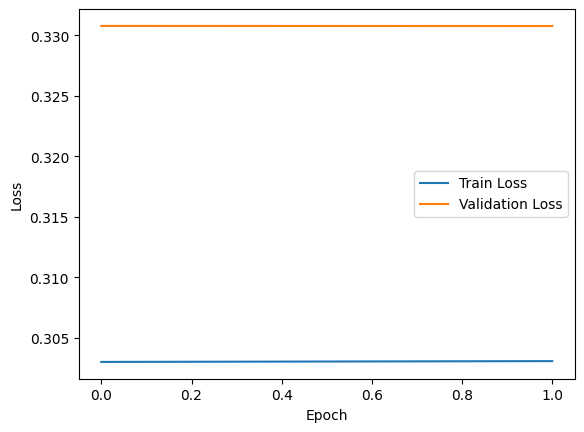

In [ ]:
plt.plot(base_train_loss, label='Train Loss')
plt.plot(base_val_loss, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [ ]:
base_model_name = f'{common_file_name}.pt'
# define the path to save the model
base_model_path = os.path.join(base_model_dir, base_model_name)

In [ ]:
# save the model to the specified path
if not os.path.exists(os.path.dirname(base_model_path)):
    os.makedirs(os.path.dirname(base_model_path))
torch.save(base_model.state_dict(), base_model_path)
print(f'The base trained model: {base_model_name} has been successfully saved: "{base_model_path}".\n')

The base trained model: TL_BM_TCN_1.0_MSE_OP_4.0_7.0_1.0_23062023.pt has been successfully saved: "/content/gdrive/My Drive/TL_A/DeepKale/experiments_0.2/result/base_result/model/TL_BM_TCN_1.0_MSE_OP_4.0_7.0_1.0_23062023.pt".



In [ ]:
if os.path.exists(base_model_path):
    base_model.load_state_dict(torch.load(base_model_path))
    base_test_loss, base_y_pred = test(device = device, model = base_model, test_loader = base_test_loader, loss_fn = base_loss_fn)
else:
    print(f"File not found at path: {base_model_path}\n")

Test Loss: 0.3243



In [ ]:
base_result_df, base_result_df_daily = process_data(
    y_test=base_y_test,
    y_pred=base_y_pred,
    scaling_type = 'robust',
    scaling_params=base_robust_scaling_params,
    connection_time_list=base_connection_time_list,
    train_df=base_train_df,
    val_df=base_val_df,
    scaled_df=base_scaled_df,
    n_past=N_PAST,
    n_future=N_FUTURE
)

In [ ]:
# Save base_result_df as pickle
base_result_df_file_name = f'{common_file_name}_base_result_df.pkl'
base_result_df_file_path = os.path.join(base_test_result_dir, base_result_df_file_name)
base_result_df.to_pickle(base_result_df_file_path)
print(f"Base result DataFrame {base_result_df_file_name} has been successfully saved: {base_result_df_file_path}.\n")

# Save base_result_df_daily as pickle
base_result_df_daily_file_name = f'{common_file_name}_base_result_df_daily.pkl'
base_result_df_daily_file_path = os.path.join(base_test_result_dir, base_result_df_daily_file_name)
base_result_df_daily.to_pickle(base_result_df_daily_file_path)
print(f"Base result daily DataFrame {base_result_df_daily_file_name} has been successfully saved: {base_result_df_daily_file_path}.\n")

Base result DataFrame has been successfully saved: /content/gdrive/My Drive/TL_A/DeepKale/experiments_0.2/result/base_result/test_result/TL_BM_TCN_1.0_MSE_OP_4.0_7.0_1.0_23062023_base_result_df.pkl.

Base result daily DataFrame has been successfully saved: /content/gdrive/My Drive/TL_A/DeepKale/experiments_0.2/result/base_result/test_result/TL_BM_TCN_1.0_MSE_OP_4.0_7.0_1.0_23062023_base_result_df_daily.pkl.



In [ ]:
base_mae, base_r2, base_mse, base_rms = performance_metrics(result_df = base_result_df_daily)

In [ ]:
print(f"Base MAE: {base_mae}")
print(f"Base R2 score: {base_r2}")
print(f"Base MSE: {base_mse}")
print(f"Base RMS: {base_rms}\n")

Base MAE: 1.405319748701791
Base R2 score: -0.006210758633118596
Base MSE: 2.61096928604011
Base RMS: 1.6158494007920756



In [ ]:
# save the performance metrics in a separate pickle file
base_performance_metrics_filename = f'{common_file_name}_performance_metrics.pkl'
base_performance_metrics_path = os.path.join(base_permormance_metrics_dir, base_performance_metrics_filename)
with open(base_performance_metrics_path, 'wb') as f:
    '''Saving the performance matrix'''
    pkl.dump({'base test loss': base_test_loss, 'base mae': base_mae, 'base r2': base_r2, 'base mse': base_mse, 'base rms': base_rms}, f)

print(f"Performance metrics for base model: {base_performance_metrics_filename} has been successfully saved to {base_performance_metrics_path}\n")

Performance metrics for base model: TL_BM_TCN_1.0_MSE_OP_4.0_7.0_1.0_23062023_performance_metrics.pkl has been successfully saved to /content/gdrive/My Drive/TL_A/DeepKale/experiments_0.2/result/base_result/performance_metrics/TL_BM_TCN_1.0_MSE_OP_4.0_7.0_1.0_23062023_performance_metrics.pkl



In [ ]:
create_line_plot(base_result_df_daily, title = 'Actual vs Predicted kWh Delivered Avg Daily-Base TCN Model')